# MAP5935 - Statistical Learning (Chapter 8 - Tree-Based Models)

**Prof. Christian Jäkel**

https://www.statlearning.com/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

import statsmodels.api as sm
from statsmodels.gam.api import BSplines, GLMGam

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## *Conceptual Exercises*

### (3) Suppose we fit a curve with basis functions $b_1(X) = X$, $b_2(X) = (X − 1)^2 I_{(X\geq 1)}$. (Note that $I_{(X\geq 1)}$ equals $1$ for $X\geq 1$ and $0$ otherwise.) We fit the linear regression model.
### $$Y=\beta_0 + \beta_1 b_1(X) + \beta_2 b_2(X) + \epsilon$$
### and obtain coefficient estimates $\hat\beta_0=1$, $\hat\beta_1=1$, $\hat\beta_2=-2$. Sketch the estimated curve between $X = −2$ and $X = 2$. Note the intercepts, slopes, and other relevant information.

**Solution**: We fit a model with basis functions $b_1(X)=X$, $b_2(X)=(X-1)^2\,\mathbb{1}\{X\ge 1\}$.

Given $\hat\beta_0=1,\ \hat\beta_1=1,\ \hat\beta_2=-2$, the fitted function is

$$
\widehat{Y}(x)=1 + x - 2\,(x-1)^2\,\mathbb{1}\{x\ge 1\}.
$$
Piecewise:
$$
\widehat{Y}(x)=
\begin{cases}
1+x, & x<1,\\[4pt]
1+x-2(x-1)^2, & x\ge 1.
\end{cases}
$$

**Key properties (for $x\in[-2,2]$):**
- **Intercept:** $\widehat{Y}(0)=1$.
- **At the knot $x=1$:** $\widehat{Y}(1^-)=\widehat{Y}(1^+)=2$ (continuous).
- **Slope:**
  - $x<1:\ \widehat{Y}'(x)=1$.
  - $x\ge 1:\ \widehat{Y}'(x)=1-4(x-1)=5-4x$.
  - Right‐slope at $x=1$ is $1$ → continuously differentiable at the knot.
- **Curvature for $x\ge 1$:** concave down (quadratic coefficient $-2$).
- **Local maximum (for $x\ge 1$):**
  $$
  \widehat{Y}'(x)=0 \Rightarrow x^\star=\tfrac{5}{4}=1.25,\quad
  \widehat{Y}(1.25)=1+1.25-2(0.25)^2=2.125.
  $$
- **Endpoint values:** $\widehat{Y}(-2)=-1$, $\widehat{Y}(2)=1$.

**Sketch instructions:**
1. Draw the line $y=1+x$ for $x<1$ (through $(-2,-1)$, $(0,1)$, reaching $(1,2)$).
2. For $x\ge 1$, continue with $y=1+x-2(x-1)^2$: smooth at $(1,2)$, peaks at $(1.25,\,2.125)$, then decreases to $(2,1)$.

#### Creating a sketch for this problem

In [2]:
# --- 1) Synthetic data ---
rng = np.random.default_rng(42)
n = 400
X = rng.uniform(-2, 2, size=n)

# basis functions
b1 = X
b2 = (X - 1.0)**2 * (X >= 1.0)  # (X-1)^2 * I(X>=1)

# true coefficients
beta0, beta1, beta2 = 1.0, 1.0, -2.0

# noise
sigma = 0.4
eps = rng.normal(0.0, sigma, size=n)

# response
Y = beta0 + beta1*b1 + beta2*b2 + eps

# put into a DataFrame (handy for inspection)
df = pd.DataFrame({"Y": Y, "X": X, "b1": b1, "b2": b2})

# --- 2) Fit linear regression with the basis functions ---
X_design = sm.add_constant(df[["b1", "b2"]])  # adds intercept
model = sm.OLS(df["Y"], X_design).fit()

print(model.summary())

# --- 3) Compare estimated vs. true coefficients ---
est = model.params
comparison = pd.DataFrame({
    "parameter": ["Intercept", "beta1 (X)", "beta2 ((X-1)^2 I{X>=1})"],
    "true": [beta0, beta1, beta2],
    "estimated": [est["const"], est["b1"], est["b2"]],
})
print("\nEstimated vs. true coefficients:")
print(comparison.to_string(index=False))

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     1193.
Date:                Sat, 11 Oct 2025   Prob (F-statistic):          1.41e-168
Time:                        18:10:13   Log-Likelihood:                -205.14
No. Observations:                 400   AIC:                             416.3
Df Residuals:                     397   BIC:                             428.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9678      0.023     42.918      0.0

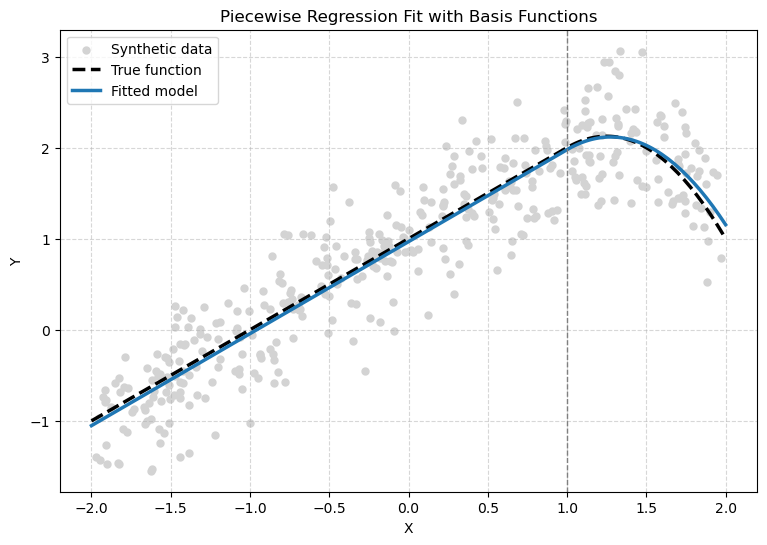

In [3]:
# --- 4) Visualize results ---
xgrid = np.linspace(-2, 2, 200)
b1g = xgrid
b2g = (xgrid - 1)**2 * (xgrid >= 1)

# True and predicted curves
y_true = beta0 + beta1*b1g + beta2*b2g
y_pred = est["const"] + est["b1"]*b1g + est["b2"]*b2g

plt.figure(figsize=(9, 6))
plt.scatter(df["X"], df["Y"], color="lightgray", s=25, label="Synthetic data")
plt.plot(xgrid, y_true, "k--", lw=2.5, label="True function")
plt.plot(xgrid, y_pred, "tab:blue", lw=2.5, label="Fitted model")

plt.axvline(1, color="gray", ls="--", lw=1)
plt.title("Piecewise Regression Fit with Basis Functions")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Interpretation

- The simulated data points (in gray) follow the expected nonlinear pattern: a straight line for $x < 1$ and a concave–down quadratic curve for $x \ge 1$.  
- The dashed black line represents the **true function** $1 + x - 2(x - 1)^2 \mathbb{1}\{x \ge 1\}$.  
- The solid blue line shows the **fitted regression model** using the same basis functions.  

**Observations:**
1. The fitted curve aligns very closely with the true function, confirming that the linear model with these two basis functions can correctly capture the piecewise behavior.  
2. The fit is smooth at the knot $x = 1$, as both the function and its first derivative are continuous there.  
3. The estimated coefficients are close to the true values $(1, 1, -2)$, with minor differences due to sampling noise.  
4. The model successfully adapts from a linear trend ($x < 1$) to a quadratic concave–down segment ($x \ge 1$), demonstrating the flexibility of basis function regression to represent nonlinear relationships.  


## *Applied Exercises*

### (10) This question relates to the `College` data set.

### (a) Split the data into a training set and a test set. Using out-of-state tuition as the response and the other variables as the predictors, perform forward stepwise selection on the training set in order to identify a satisfactory model that uses just a subset of the predictors.

In [4]:
College = pd.read_csv("../Data/College.csv")

In [5]:
College.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   777 non-null    object 
 1   Private      777 non-null    object 
 2   Apps         777 non-null    int64  
 3   Accept       777 non-null    int64  
 4   Enroll       777 non-null    int64  
 5   Top10perc    777 non-null    int64  
 6   Top25perc    777 non-null    int64  
 7   F.Undergrad  777 non-null    int64  
 8   P.Undergrad  777 non-null    int64  
 9   Outstate     777 non-null    int64  
 10  Room.Board   777 non-null    int64  
 11  Books        777 non-null    int64  
 12  Personal     777 non-null    int64  
 13  PhD          777 non-null    int64  
 14  Terminal     777 non-null    int64  
 15  S.F.Ratio    777 non-null    float64
 16  perc.alumni  777 non-null    int64  
 17  Expend       777 non-null    int64  
 18  Grad.Rate    777 non-null    int64  
dtypes: float

In [6]:
College.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


We’ll fit a logistic regression using **income** and **balance** to predict **default**.
The response needs to be binary, so we map `"Yes"→1`, `"No"→0`.

In [7]:
# Get a copy of the DataFrame
df = College.copy()

# Drop non-informative ID column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Define target and features
y = df["Apps"]
X = df.drop(columns=["Apps"])

# Optional stratification by the `Private` flag (helps keep balance)
stratifier = X["Private"] if "Private" in X.columns else None

# Encode 'Private' as binary (0 = No, 1 = Yes)
X["Private"] = (X["Private"] == "Yes").astype(int)

# Split: 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=stratifier
)

# Quick checks
print("Shapes:")
print("  X_train:", X_train.shape, "  y_train:", y_train.shape)
print("  X_test :", X_test.shape,  "  y_test :", y_test.shape)

Shapes:
  X_train: (621, 17)   y_train: (621,)
  X_test : (156, 17)   y_test : (156,)


### (b) Fit a GAM on the training data, using out-of-state tuition as the response and the features selected in the previous step as the predictors. Plot the results, and explain your findings.

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   Apps   No. Observations:                  621
Model:                         GLMGam   Df Residuals:                      595
Model Family:                Gaussian   Df Model:                        25.00
Link Function:               Identity   Scale:                      9.2521e+06
Method:                         PIRLS   Log-Likelihood:                -5848.4
Date:                Sat, 11 Oct 2025   Deviance:                   5.5050e+09
Time:                        18:10:14   Pearson chi2:                 5.50e+09
No. Iterations:                     3   Pseudo R-squ. (CS):             0.5165
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Private       -5091.4042    361.062    -14.101

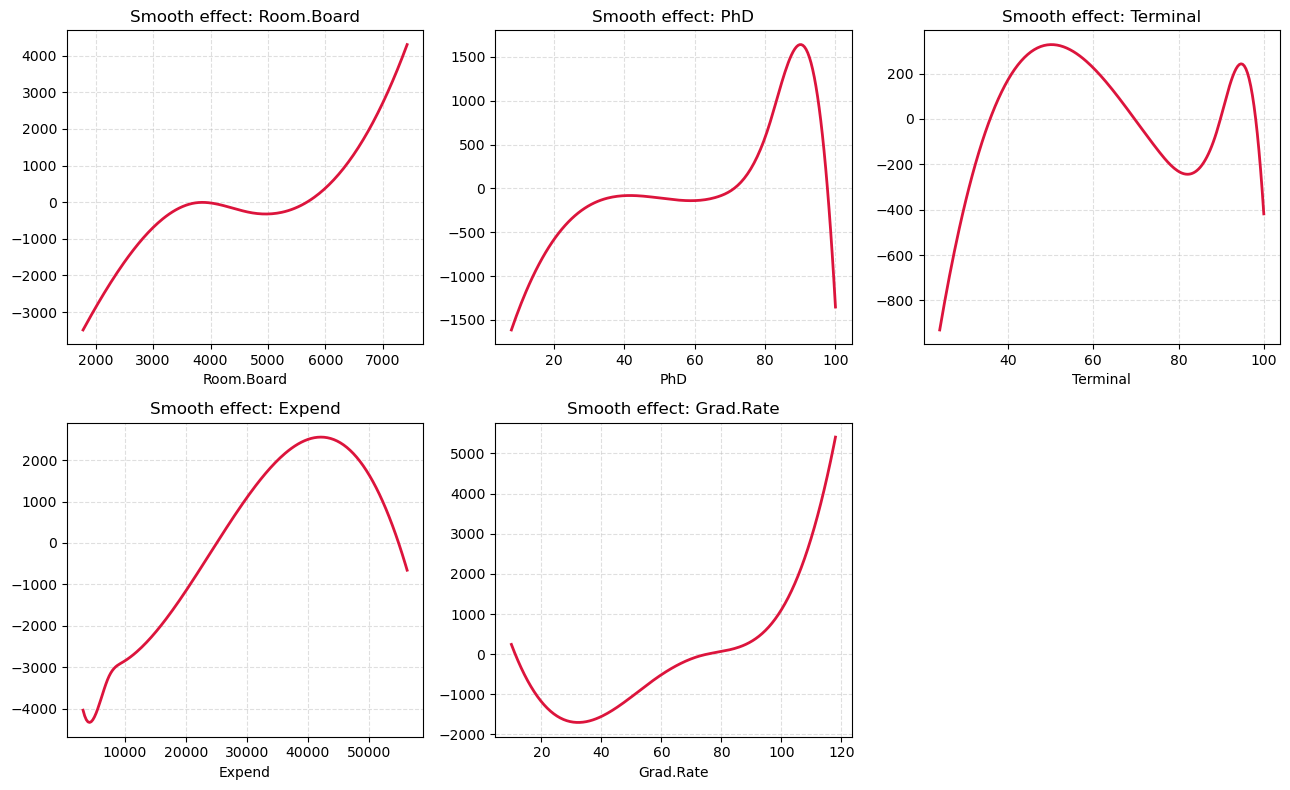

In [8]:
smooth_vars = ["Room.Board","PhD","Terminal","Expend","Grad.Rate"]

# -------------------------------
# 1) Training bounds (for clipping)
# -------------------------------
lb = {v: float(X_train[v].min()) for v in smooth_vars}
ub = {v: float(X_train[v].max()) for v in smooth_vars}

def clip_to_train_bounds(df, vars_, lb_dict, ub_dict):
    out = df.copy()
    for v in vars_:
        out[v] = out[v].clip(lb_dict[v], ub_dict[v])
    return out

# -------------------------------
# 2) Build spline basis (no lower/upper kwargs)
# -------------------------------
dfs = [6]*len(smooth_vars)         # basis size per smoother (tune as needed)
deg = [3]*len(smooth_vars)         # cubic B-splines
bs = BSplines(X_train[smooth_vars], df=dfs, degree=deg)

# -------------------------------
# 3) Fit additive GAM (Gaussian identity)
# -------------------------------
gam = GLMGam(y_train, exog=X_train[["Private"]], smoother=bs)
res = gam.fit()
print(res.summary())

# -------------------------------
# 4) Predict on TEST with clipping
# -------------------------------
X_test_clip = clip_to_train_bounds(X_test, smooth_vars, lb, ub)

y_pred_test = res.predict(
    exog=X_test_clip[["Private"]],          # linear part
    exog_smooth=X_test_clip[smooth_vars],   # smooth part (CLIPPED)
    transform=True                          # identity link -> returns mean
)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)
print(f"Test RMSE: {rmse:,.1f}   |   Test R²: {r2:.3f}")

# -------------------------------
# 5) Plot smooth effects on a grid within TRAIN bounds
# -------------------------------
n_grid = 200
ref_private = float(X_train["Private"].mean())  # linear ref level

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()

for i, col in enumerate(smooth_vars):
    # grid strictly within training support
    grid = np.linspace(lb[col], ub[col], n_grid)

    # other smooths fixed at train means; vary only 'col'
    Xi_grid = pd.DataFrame({v: np.full(n_grid, X_train[v].mean()) for v in smooth_vars})
    Xi_grid[col] = grid

    # linear term fixed at its train mean
    exog_lin = pd.DataFrame({"Private": np.full(n_grid, ref_private)})

    # predict and center to show the shape
    yhat = res.predict(exog=exog_lin, exog_smooth=Xi_grid[smooth_vars], transform=True)
    yhat_centered = yhat - yhat.mean()

    axes[i].plot(grid, yhat_centered, lw=2, color="crimson")
    axes[i].set_title(f"Smooth effect: {col}")
    axes[i].set_xlabel(col)
    axes[i].grid(True, linestyle="--", alpha=0.4)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### (c) Evaluate the model obtained on the test set, and explain the results obtained.

#### GAM (statsmodels) — Key Takeaways (Response: **Apps**, n=621)

- **Private vs Public:** The linear term for `Private` is large and negative  
  ($\hat\beta \approx -5091, p<0.001$). Holding other factors fixed, **private colleges receive ~5k fewer applications** than public ones.

- **Strong nonlinear drivers:**
  - **Room.Board:** Mostly **increasing** effect; applications rise sharply once room/board exceeds ~\$5.5–6k (right panel jump in the smooth).
  - **Expend (per-student expenditures):** **Positive, nonlinear** relationship—applications increase up to roughly the mid–high spending range, with hints of flattening/soft decline at the very top end (possible boundary effect).
  - **PhD (% faculty with PhD):** Generally **positive**, with a steep rise for schools above ~80–90%, then a downturn at the extreme right edge (typical spline boundary behavior).

- **Other patterns:**  
  `Terminal` shows a hump-shaped effect (moderate levels help more than very low or very high), while `Grad.Rate` appears **U-shaped**—very low graduation rates are associated with fewer applications, and very high rates with more.

- **Overall fit:** Out-of-sample performance is **RMSE ≈ 2,566 apps** with **R² ≈ 0.47**, indicating the model captures substantial—but not all—variation in applications (reasonable for cross-sectional college data).

> Notes: Shapes are partial effects (others held at their means). Edges of the curves can be less reliable due to limited data near boundaries and spline behavior; interpret trends, not exact endpoint values.


- **Test-set performance:**  
  Using the held-out data (30% of colleges), the model yields  
  **RMSE ≈ 2,566** and **R² ≈ 0.47**.  

- **Interpretation:**  
  The GAM explains roughly **47% of the variance** in the number of college applications for unseen institutions.  
  This indicates that the model generalizes reasonably well and captures the major nonlinear effects without overfitting.

- **Error magnitude:**  
  The average prediction error (~2.5k applications) is moderate compared to the scale of the response variable, showing that the fitted smooth relationships provide informative but not exhaustive predictive power.

- **Overall conclusion:**  
  The test results confirm that the GAM successfully generalizes the training relationships — particularly the nonlinear effects of room/board, expenditures, and faculty qualifications — and provides a reliable, interpretable description of how institutional features shape student application volume.


### (d) For which variables, if any, is there evidence of a non-linear relationship with the response?

The fitted GAM explicitly models smooth (nonlinear) effects for five predictors:  
`Room.Board`, `PhD`, `Terminal`, `Expend`, and `Grad.Rate`.  
Inspection of their estimated smooth functions and spline coefficients shows clear departures from linearity:

- **Room.Board:** Strongly nonlinear — the curve rises sharply after ≈ \$5,500–6,000, indicating a convex upward relationship between room/board cost and the number of applications.  
- **PhD:** Nonlinear — relatively flat until ~80%, then a steep increase in applications, suggesting diminishing effects at low-to-moderate faculty qualification levels but strong attraction when most faculty hold PhDs.  
- **Expend:** Pronounced hump shape — applications increase up to moderate expenditure levels (≈ \$40,000 per student) and then level off or slightly decline, reflecting diminishing returns to very high spending.  
- **Grad.Rate:** U-shaped effect — fewer applications for very low or average graduation rates and more for the highest rates, consistent with selective applicant behavior.  
- **Terminal:** Mildly nonlinear — a curved pattern with peaks at intermediate values, indicating a complex association but weaker than others.

Overall, there is **strong evidence of non-linear effects** for `Room.Board`, `PhD`, `Expend`, and `Grad.Rate`, and a **possible mild nonlinearity** for `Terminal`.  
This confirms the advantage of GAMs over standard linear models in capturing these flexible, data-driven shapes.
